<a href="https://colab.research.google.com/github/vidhu-psit/Learn-Python-Git/blob/master/DeepLearning/9_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#Source and Reference: https://blog.keras.io/building-autoencoders-in-keras.html


import keras
from keras import layers
from keras.datasets import mnist
import numpy as np



(x_train, y_train), (x_test, y_test) = mnist.load_data()

#Normalization of input
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

#Reshaping the images to 1D vectors
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


In [ ]:
print(y_train.shape)
print(y_test.shape)

(60000,)
(10000,)


In [ ]:
# from keras import Sequential, layers

# autoencoder = Sequential([
#    layers.Input(shape=(784,)),
#    layers.Dense(128, activation="relu"),
#    layers.Dense(64, activation="relu"),
#    layers.Dense(32, activation="relu"),
#    layers.Dense(64, activation="relu"),
#    layers.Dense(128, activation="relu"),
#    layers.Dense(784, activation="sigmoid")
# ])

# autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

# autoencoder.fit(
#    x_train, x_train,
#    epochs=10,
#    batch_size=256,
#    shuffle=True,
#    validation_data=(x_test, x_test)
# )

# Keras Functional API

In [ ]:
#AutoEncoder model - Functional
input_img = keras.Input(shape=(784,))

encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = keras.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2465 - val_loss: 0.1682
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1508 - val_loss: 0.1371
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1316 - val_loss: 0.1247
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1223 - val_loss: 0.1176
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1166 - val_loss: 0.1129
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1128 - val_loss: 0.1097
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1097 - val_loss: 0.1065
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1069 - val_loss: 0.1048
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1050 - val_loss: 0.1032
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1035 - val_loss: 0.1019


In [ ]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,154 (2.54 MB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444,770 (1.70 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


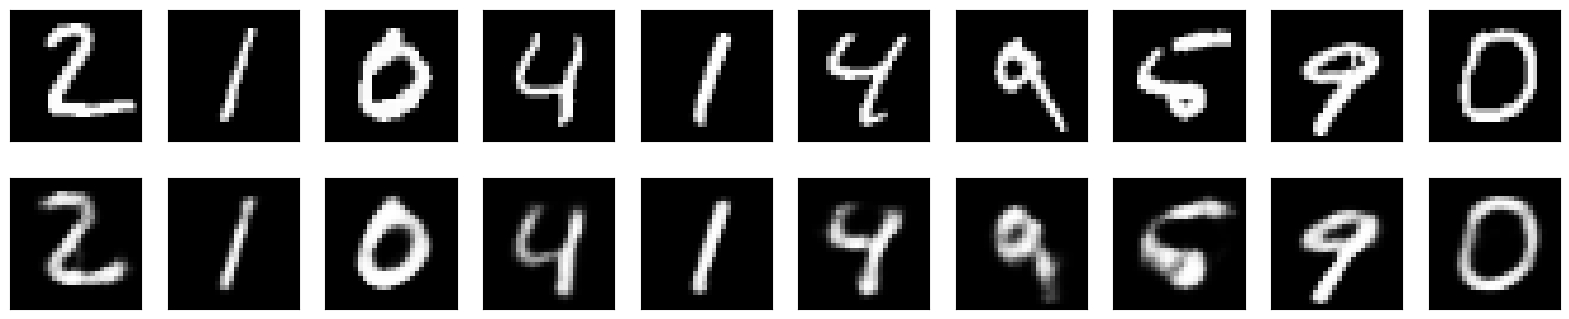

In [ ]:
#Visualize the outputs
import matplotlib.pyplot as plt

decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Model: "functional_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 223,834 (874.35 KB)
 Trainable params: 223,834 (874.35 KB)
 Non-trainable params: 0 (0.00 B)

# Let's have bottle-neck layer as size 2

In [ ]:

#AutoEncoder model for 2D encoding
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)
encoded = layers.Dense(16, activation='relu')(encoded)
encoded = layers.Dense(8, activation='relu')(encoded)
encoded = layers.Dense(4, activation='relu')(encoded)
encoded = layers.Dense(2, activation='relu')(encoded)

decoded = layers.Dense(4, activation='relu')(encoded)
decoded = layers.Dense(8, activation='relu')(decoded)
decoded = layers.Dense(16, activation='relu')(decoded)
decoded = layers.Dense(32, activation='relu')(decoded)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)



In [ ]:
model = keras.Model(input_img, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')


In [ ]:
model.fit(x_train, x_train,
                epochs=100,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.3280 - val_loss: 0.2484
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2399 - val_loss: 0.2338
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2309 - val_loss: 0.2277
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2266 - val_loss: 0.2241
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2235 - val_loss: 0.2215
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2212 - val_loss: 0.2195
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2194 - val_loss: 0.2179
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2179 - val_loss: 0.2162
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2173 - val_loss: 0.2164
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2158 - val_loss: 0.2164
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2158 - val_loss: 0.2147
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 671,504 (2.56 MB)

 Trainable params: 223,834 (874.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 447,670 (1.71 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


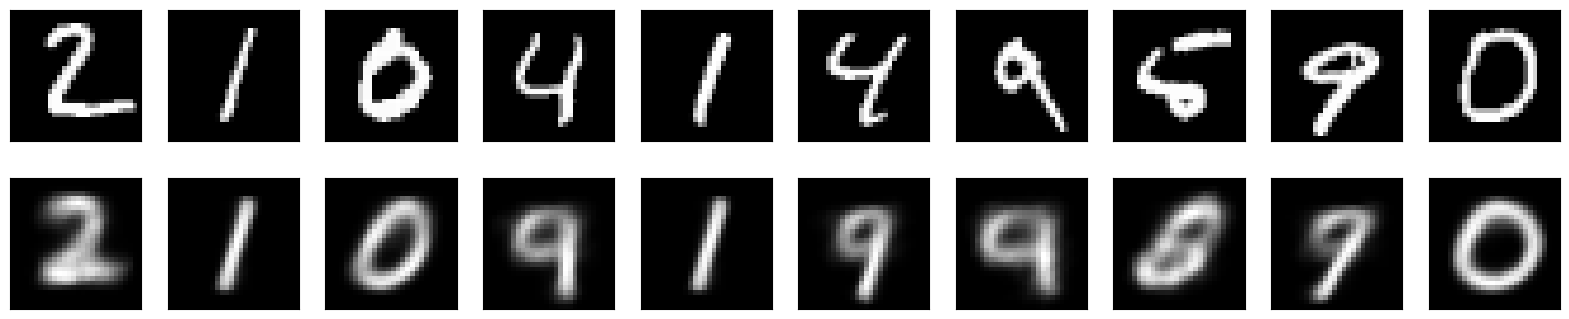

In [ ]:
#Visualize the outputs
import matplotlib.pyplot as plt

decoded_imgs = model.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
model.layers

[<InputLayer name=input_layer_1, built=True>,
 <Dense name=dense_6, built=True>,
 <Dense name=dense_7, built=True>,
 <Dense name=dense_8, built=True>,
 <Dense name=dense_9, built=True>,
 <Dense name=dense_10, built=True>,
 <Dense name=dense_11, built=True>,
 <Dense name=dense_12, built=True>,
 <Dense name=dense_13, built=True>,
 <Dense name=dense_14, built=True>,
 <Dense name=dense_15, built=True>,
 <Dense name=dense_16, built=True>,
 <Dense name=dense_17, built=True>,
 <Dense name=dense_18, built=True>,
 <Dense name=dense_19, built=True>]

In [ ]:
model.layers[7].output

<KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>

In [ ]:
dim_2_model = keras.Model(model.input, model.layers[7].output)

In [ ]:
dim_2d = dim_2_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
dim_2d.shape

(10000, 2)

In [ ]:
# dim_2d.save('dim_2d.keras')

NameError: name 'dim_2d' is not defined

# Denoising Autoencoder

In [ ]:
from keras.datasets import mnist
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

#Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

#Reshape
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

#add NOISE - adding noise with random normal distribution
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print(x_train.shape)
print(x_train_noisy.shape)
print(x_test.shape)
print(x_test_noisy.shape)

(60000, 784)
(60000, 784)
(10000, 784)
(10000, 784)


In [ ]:
np.random.normal(loc=0.0, scale=1.0, size=x_train.shape).shape

(60000, 784)

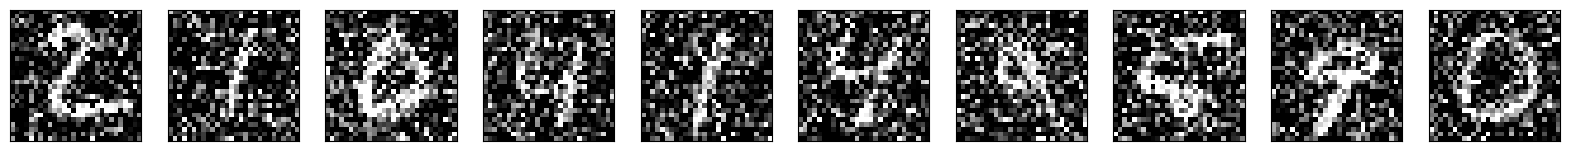

In [ ]:
#Visualize the outputs
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [ ]:
#AutoEncoder model
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# Compile and Fit
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_noisy, x_train, # NOTE: input is noisy, output is non-noisy
                epochs=100,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.2577 - val_loss: 0.1965
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1842 - val_loss: 0.1716
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1652 - val_loss: 0.1580
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1556 - val_loss: 0.1507
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1497 - val_loss: 0.1476
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1455 - val_loss: 0.1428
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1421 - val_loss: 0.1395
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1394 - val_loss: 0.1372
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1368 - val_loss: 0.1351
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1349 - val_loss: 0.1350
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1335 - val_loss: 0.1320
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


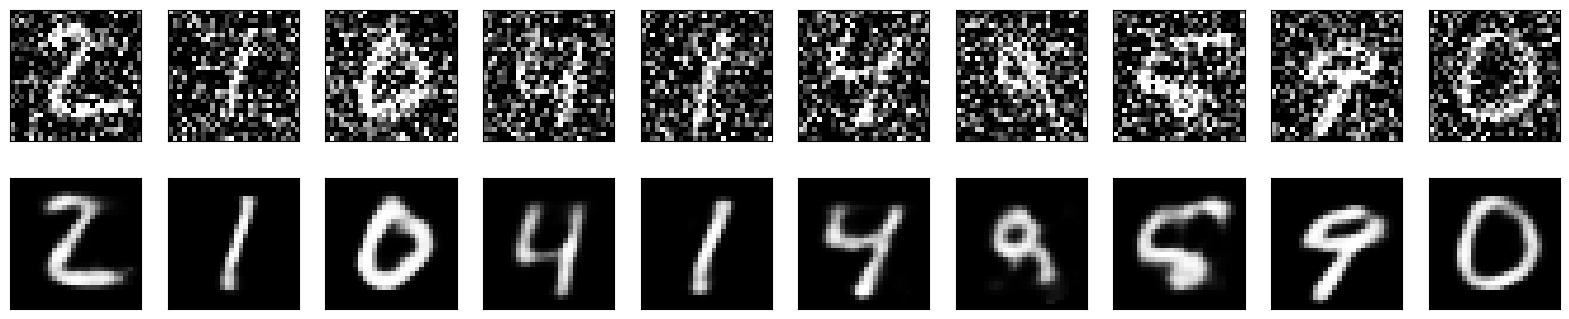

In [ ]:
#Visualize the outputs
import matplotlib.pyplot as plt

decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# Movie Recommendation

In [ ]:
import numpy as np
import pandas as pd


import warnings
warnings.filterwarnings('ignore')

In [ ]:
!gdown 1EsPvxcp5lzdltC3yLar1_laArmk9RZpw
!gdown 1DgdthLfHLIq3AnS4YAa1bne-OM90oHoD

Downloading...
From: https://drive.google.com/uc?id=1EsPvxcp5lzdltC3yLar1_laArmk9RZpw
To: /content/ratings.csv
100% 2.48M/2.48M [00:00<00:00, 17.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DgdthLfHLIq3AnS4YAa1bne-OM90oHoD
To: /content/movies.csv
100% 516k/516k [00:00<00:00, 7.24MB/s]


In [ ]:
ratings = pd.read_csv('ratings.csv')

In [ ]:
ratings.shape

(105339, 4)

In [ ]:
ratings.movieId.unique().shape

(10325,)

In [ ]:
rm = ratings.pivot(index = 'movieId', columns ='userId', values = 'rating').fillna(0)
rm.head()

userId,1,2,3,4,5,6,7,8,9,10,...,659,660,661,662,663,664,665,666,667,668
movieId,,,,,,,,,,,,,,,,,,,,,
1,0.0,5.0,0.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,4.0,5.0,3.0,0.0,0.0,0.0,0.0,3.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,3.0
3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,0.0,...,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,3.0,3.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.5


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train, val = train_test_split(rm, test_size = 0.2)

In [ ]:
X_train = train.values
X_train.shape


(8260, 668)

In [ ]:
X_val = val.values

In [ ]:
input_movie = keras.Input(shape=(668,))
encoded = layers.Dense(512, activation='relu')(input_movie)
encoded = layers.BatchNormalization()(encoded)
encoded = layers.Dense(256, activation='relu')(encoded)
encoded = layers.BatchNormalization()(encoded)
encoded = layers.Dense(128, activation='relu')(encoded)
encoded = layers.BatchNormalization()(encoded)


decoded = layers.Dense(256, activation='relu')(encoded)
decoded = layers.BatchNormalization()(decoded)
decoded = layers.Dense(512, activation='relu')(decoded)
decoded = layers.BatchNormalization()(decoded)
decoded = layers.Dense(668, activation='linear')(decoded)

In [ ]:
autoencoder = keras.Model(input_movie, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
autoencoder.fit(X_train, X_train,
                epochs=100,
                batch_size=256,
                shuffle=True,
                validation_data=(X_val, X_val))

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.3856 - val_loss: 0.7422
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1634 - val_loss: 0.2285
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1498 - val_loss: 0.1677
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1440 - val_loss: 0.1547
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1418 - val_loss: 0.1515
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1367 - val_loss: 0.1425
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1319 - val_loss: 0.1398
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1284 - val_loss: 0.1371
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1257 - val_loss: 0.1417
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1245 - val_loss: 0.1311
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1204 - val_loss: 0.1304
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

In [ ]:
autoencoder.summary()

### Saving and Loading Keras Models with `joblib` and `pickle`

Keras models can be saved and loaded using Python's built-in `pickle` module or the `joblib` library, which is optimized for NumPy arrays and objects containing large NumPy arrays. This is useful for persisting trained models to disk and reusing them later without retraining.

#### Using `joblib` to save and load the `autoencoder` model

In [ ]:
import joblib

# Define the filename for the joblib saved model
joblib_model_filename = 'autoencoder_joblib.pkl'

# Save the autoencoder model using joblib
joblib.dump(autoencoder, joblib_model_filename)
print(f"Model saved to {joblib_model_filename} using joblib.")

In [ ]:
# Load the autoencoder model using joblib
loaded_autoencoder_joblib = joblib.load(joblib_model_filename)
print(f"Model loaded from {joblib_model_filename} using joblib.")

# Verify the loaded model
loaded_autoencoder_joblib.summary()

#### Using `pickle` to save and load the `autoencoder` model

Note: While `pickle` can save Keras models, it's generally recommended to use `joblib` for models that might contain large numerical arrays, or Keras's built-in `save()` and `load_model()` methods for more robust and version-compatible saving.

In [ ]:
import pickle

# Define the filename for the pickle saved model
pickle_model_filename = 'autoencoder_pickle.pkl'

# Save the autoencoder model using pickle
with open(pickle_model_filename, 'wb') as file:
    pickle.dump(autoencoder, file)
print(f"Model saved to {pickle_model_filename} using pickle.")

In [ ]:
# Load the autoencoder model using pickle
with open(pickle_model_filename, 'rb') as file:
    loaded_autoencoder_pickle = pickle.load(file)
print(f"Model loaded from {pickle_model_filename} using pickle.")

# Verify the loaded model
loaded_autoencoder_pickle.summary()

In [ ]:
autoencoder.layers[3].output

In [ ]:
intermediate_model = keras.Model(autoencoder.input, autoencoder.layers[3].output)


In [ ]:
rm.values.shape

In [ ]:
embeddings = intermediate_model.predict(rm.values)
embeddings.shape

323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10325, 128)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
similarity_matrix = cosine_similarity(embeddings)

In [ ]:
similarity_matrix.shape

(10325, 10325)

In [ ]:
similarity_matrix[0]

array([1.0000001 , 0.68231374, 0.6857738 , ..., 0.5323958 , 0.55453223,
       0.5185046 ], dtype=float32)

In [ ]:
item_sim_matrix = pd.DataFrame(similarity_matrix, index=rm.index, columns=rm.index)
item_sim_matrix.head() #Item-similarity Matrix

movieId,1,2,3,4,5,6,7,8,9,10,...,144482,144656,144976,146344,146656,146684,146878,148238,148626,149532
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.682314,0.685774,0.552098,0.688199,0.620111,0.680534,0.668955,0.608330,0.665730,...,0.606679,0.524637,0.543933,0.558892,0.549605,0.464704,0.492516,0.532396,0.554532,0.518505
2,0.682314,1.000000,0.687073,0.721744,0.668640,0.650301,0.633833,0.734556,0.630861,0.733953,...,0.740170,0.651015,0.637094,0.681770,0.696931,0.578630,0.603781,0.657880,0.662229,0.645572
3,0.685774,0.687073,1.000000,0.717697,0.880010,0.682814,0.811179,0.819225,0.780719,0.665157,...,0.707126,0.638374,0.664718,0.665998,0.677068,0.634909,0.652167,0.644951,0.671758,0.633563
4,0.552098,0.721744,0.717697,1.000000,0.697172,0.721734,0.754129,0.814172,0.766749,0.713859,...,0.749158,0.688110,0.728313,0.709563,0.728310,0.662083,0.670425,0.693340,0.725568,0.683811
5,0.688199,0.668640,0.880010,0.697172,1.000000,0.673433,0.834900,0.769078,0.786860,0.696616,...,0.696808,0.639292,0.614444,0.665628,0.674376,0.561879,0.583106,0.645803,0.637029,0.634198


In [ ]:
movies = pd.read_csv('movies.csv')
movies[movies.title.str.contains('Liar Liar')]

,movieId,title,genres
1202,1485,Liar Liar (1997),Comedy


In [ ]:
item_sim_matrix[1485].sort_values(ascending=False).head(10)

,1485
movieId,
1485,1.000000
104,0.879901
1407,0.879720
1438,0.862885
1646,0.858854
1604,0.848194
1517,0.847772
2321,0.847505
1777,0.846720


In [ ]:
movie_index = item_sim_matrix[1485].sort_values(ascending=False).head(10).index
movies[movies.movieId.isin(movie_index)]

,movieId,title,genres
94,104,Happy Gilmore (1996),Comedy
1143,1407,Scream (1996),Comedy|Horror|Mystery|Thriller
1166,1438,Dante's Peak (1997),Action|Thriller
1202,1485,Liar Liar (1997),Comedy
1225,1517,Austin Powers: International Man of Mystery (1...,Action|Adventure|Comedy
1284,1604,Money Talks (1997),Action|Comedy
1315,1646,RocketMan (a.k.a. Rocket Man) (1997),Children|Comedy|Romance|Sci-Fi
1398,1777,"Wedding Singer, The (1998)",Comedy|Romance
1835,2321,Pleasantville (1998),Comedy|Drama|Fantasy
2499,3120,"Distinguished Gentleman, The (1992)",Comedy
